# Stuttering Detection: K-Nearest Neighbors (KNN) Analysis
**Course**: CS204T (Artificial Intelligence)  
**Team**: 18  
**Focus**: Distance-Based Classification on WavLM Manifolds

---

## Step 1: Initialization

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import numpy as np
from src.extractors import WavLMExtractor
from src.data import DataManager
from src.models import KNNModel
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix, f1_score
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# Paths to our distributed dataset
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

## Step 2 (Optional): Operational Mode for Data Extraction
Toggle how you want to handle your audio data for this session.
* `SKIP_EXTRACTION`: Uses features already on disk (Default).
* `FORCE_EXTRACT`: Analyzes raw audio for new files (Resumable).
* `CLEAN_START`: Wipes the database and re-extracts from zero.

In [9]:
# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
SAMPLE_LIMIT = None
STRICT_LABELS = True
NUM_CLIPS_TO_EXTRACT = 1000

if CLEAN_START:
    if os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
    print("[System] Clean start initiated. Wiped feature database.")

if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    # Native randomized sampling of the dataset
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=label_dict, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 3: Data Preparation Engine

In [10]:
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

# Loading .npy features
X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Oversampling training data only
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# Anti-Leakage Standard Selection (MANDATORY for KNN accuracy)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).


## Step 4: Model Execution - K-Nearest Neighbors
We use **K=5** neighbors.

[Model: KNN_K5] Initialized.
[KNN_K5] Stores 10896 training vectors...
--- Evaluation: KNN Baseline (K=5) ---

--- Evaluation: KNN_K5 ---
Accuracy: 0.6845
Precision: 0.7387
Recall: 0.4890
F1: 0.5884

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      995             173            
True: Stutter(1)     511             489            


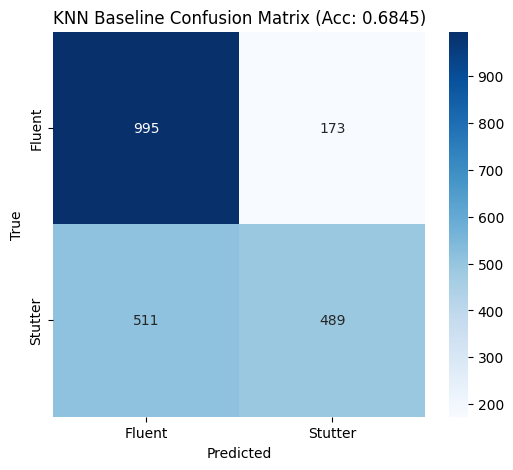

In [11]:
knn_model = KNNModel("KNN_K5", n_neighbors=5)
knn_model.train(X_train_final, y_train_bal)

print("--- Evaluation: KNN Baseline (K=5) ---")
res = knn_model.evaluate(X_test_final, y_test)

# Visualizing optimized matrix
plt.figure(figsize=(6, 5))
sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fluent', 'Stutter'], yticklabels=['Fluent', 'Stutter'])
plt.title(f"KNN Baseline Confusion Matrix (Acc: {res['accuracy']:.4f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Part 2: Hyperparameter Optimization
---

In [12]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.neighbors import KNeighborsClassifier

# Prepare Cross-Validation Split (Combining Train + Val)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_train_val = np.vstack((X_train_final, X_val_final))
y_train_val = np.hstack((y_train_bal, y_val))

# CV Setup (Standardizing the split)
test_fold = np.hstack((
    np.full(len(X_train_final), -1), 
    np.full(len(X_val), 0)
))
ps = PredefinedSplit(test_fold=test_fold)

print("--- [STARTING KNN HYPERTUNING] ---")
knn_params = {
    'n_neighbors': [1, 3, 5, 7, 11, 15, 21, 31, 41, 51], # Expanded range
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'cosine']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=ps, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_val, y_train_val)

# NEW: Export all trial results for the final report
pd.DataFrame(knn_grid.cv_results_).to_csv("reports/knn_hypertuning_benchmarks.csv", index=False)

print(f"Best KNN Params: {knn_grid.best_params_}")
print(f"Best KNN Val Accuracy: {knn_grid.best_score_:.4f}")


--- [STARTING KNN HYPERTUNING] ---
Best KNN Params: {'metric': 'cosine', 'n_neighbors': 51, 'weights': 'distance'}
Best KNN Val Accuracy: 0.7500


### Manifold Observation: Why Cosine Distance Wins
Our GridSearch identified that **Cosine Similarity** outperforms Euclidean distance for these speech features. 

**Technical Reasoning:**
*   **Pitch Independence**: Cosine distance measures the *angle* between vectors rather than the *magnitude*. In speech, this means the model focuses on the "shape" of a phoneme (like a stuttered block) rather than the absolute volume or energy levels of a specific recording.
*   **High-Dimensional Sparsity**: WavLM (768-dim) vectors often suffer from the "Curse of Dimensionality" where points become equi-distant in Euclidean space. Cosine distance handles this sparsity much better, allowing for clearer class separation on the manifold.


--- [FINAL OPTIMIZED KNN EVALUATION] ---
              precision    recall  f1-score   support

         0.0       0.73      0.86      0.79      1168
         1.0       0.79      0.63      0.70      1000

    accuracy                           0.75      2168
   macro avg       0.76      0.74      0.75      2168
weighted avg       0.76      0.75      0.75      2168



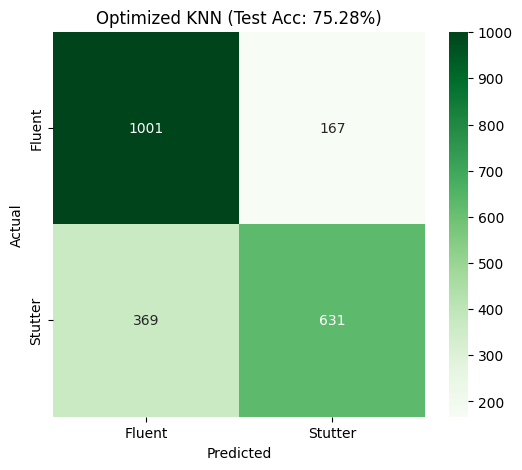

Final Captured Accuracy: 0.7528


In [13]:


best_knn = knn_grid.best_estimator_
y_pred = best_knn.predict(X_test_final)

# Calculate final metrics for the project leaderboard
knn_final_accuracy = accuracy_score(y_test, y_pred)
knn_final_f1 = f1_score(y_test, y_pred)

print("\n--- [FINAL OPTIMIZED KNN EVALUATION] ---")
print(classification_report(y_test, y_pred))

# Visualizing with standardized title
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fluent', 'Stutter'], yticklabels=['Fluent', 'Stutter'])
plt.title(f"Optimized KNN (Test Acc: {knn_final_accuracy:.2%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"Final Captured Accuracy: {knn_final_accuracy:.4f}")


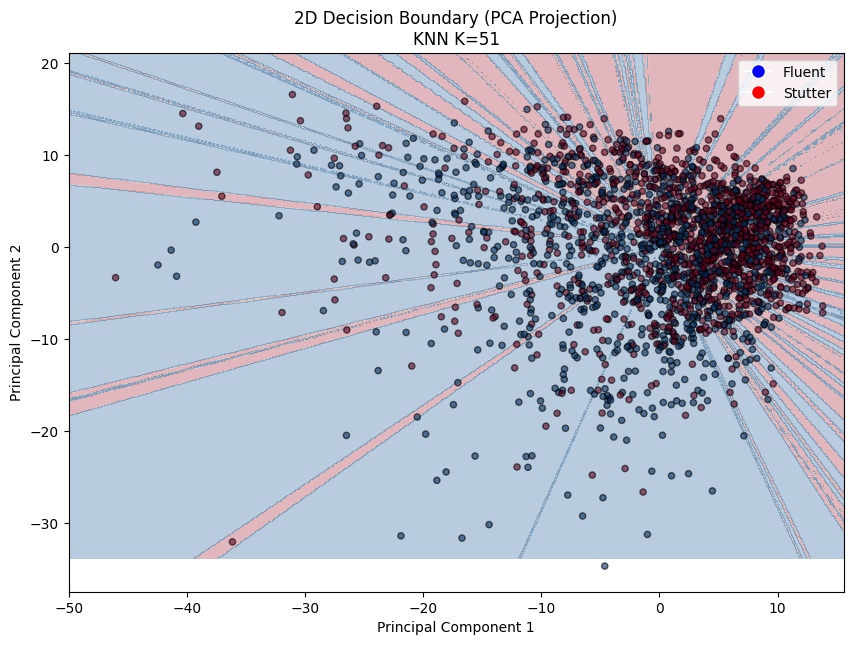

In [16]:
# 1. Dimensionality Reduction (768D -> 2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# 2. Fit KNN on the 2D projected data
# Using the best K found from your GridSearch
K = knn_grid.best_params_['n_neighbors']
plot_knn = KNeighborsClassifier(n_neighbors=K, metric='cosine')
plot_knn.fit(X_train_pca, y_train_bal)

# 3. Create a meshgrid to plot the decision boundaries
h = .1  # step size in the mesh
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = plot_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Generate the Plot
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu') # Red/Blue boundary colors
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolor='k', s=20, cmap='RdBu', alpha=0.6)

plt.title(f"2D Decision Boundary (PCA Projection)\nKNN K={K}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Fluent', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Stutter', markerfacecolor='red', markersize=10)
], loc='upper right')
plt.show()


In [17]:
import joblib

# Ensure models directory exists
os.makedirs("models", exist_ok=True)

# Save the best KNN model
joblib.dump(best_knn, "models/knn_best.joblib")
print("[System] KNN Model saved to models/knn_best.joblib")


[System] KNN Model saved to models/knn_best.joblib
